# Environment & Imports

In [1]:
import sys
import os

# Make src/ importable from any notebook
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Core libraries
import qiskit
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Analysis libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency

# Project modules
from src.circuit_generator import generate_random_circuit
from src.runners import run_circuit, run_vqe_trace, run_vqe_experiment, run_vqe_trace_shots
from src.checker import (
    check_violation,
    print_comparison,
    counts_to_probabilities,
    distribution_distance,
    compare_vqe_traces,
    check_vqe_violation,
    evaluate_vqe_pair,
    evaluate_vqe_pair_shot_based,
    evaluate_vqe_pair_noisy,
)
from src.analyzer import ResultAnalyzer

from src.transformations import (
    identity_transformation,
    barrier_only,
    commute_independent,
    fault_add_x,
    fault_remove_random_gate,
    fault_change_target_qubit,
    vqe_identity,
    vqe_barrier,
    vqe_identity_xx,
    vqe_fault_x,
    vqe_fault_replace_rotation,
    vqe_fault_shift_parameter,
    vqe_fault_change_entanglement,
    vqe_fault_replace_rotation_strong,
    vqe_fault_shift_parameter_strong,
    
)

print("All imports successful.")
print("Qiskit version:", qiskit.__version__)
print("Project root:", project_root)

All imports successful.
Qiskit version: 2.3.0
Project root: C:\Users\shask\Desktop\metamorphic_quantum_testing-20260507T174858Z-3-001\metamorphic_quantum_testing


In [2]:
sim = AerSimulator()

print("AerSimulator initialized successfully.")
print(sim)

AerSimulator initialized successfully.
AerSimulator('aer_simulator')


In [3]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

counts_1 = run_circuit(qc, shots=4096, seed=42)
counts_2 = run_circuit(qc, shots=4096, seed=42)

print("Bell-state counts (run 1):", counts_1)
print("Bell-state counts (run 2):", counts_2)
print("Reproducible with same seed?", counts_1 == counts_2)

Bell-state counts (run 1): {'11': 2087, '00': 2009}
Bell-state counts (run 2): {'11': 2087, '00': 2009}
Reproducible with same seed? True


Random circuit generated successfully.
Depth: 4
Number of qubits: 3


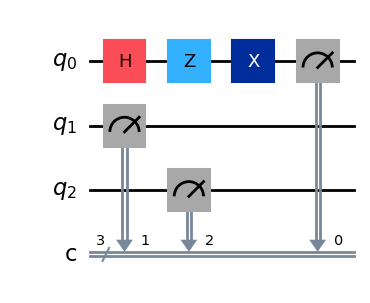

In [4]:
qc_random = generate_random_circuit(
    num_qubits=3,
    depth=5,
    add_measurements=True,
    seed=42,
)

print("Random circuit generated successfully.")
print("Depth:", qc_random.depth())
print("Number of qubits:", qc_random.num_qubits)

qc_random.draw("mpl")

In [5]:
# Transformation check

qc_src = generate_random_circuit(
    num_qubits=3,
    depth=5,
    add_measurements=True,
    seed=42,
)

qc_id = identity_transformation(qc_src, seed=42)
qc_barrier = barrier_only(qc_src, seed=42)
qc_commute = commute_independent(qc_src, seed=42)

print("Original and identity-transformed circuits differ structurally?", qc_src != qc_id)
print("Original and barrier-transformed circuits differ structurally?", qc_src != qc_barrier)
print("Original and commute-transformed circuits differ structurally?", qc_src != qc_commute)

print("\nOriginal depth:", qc_src.depth())
print("Identity depth:", qc_id.depth())
print("Barrier depth:", qc_barrier.depth())
print("Commute depth:", qc_commute.depth())

Original and identity-transformed circuits differ structurally? True
Original and barrier-transformed circuits differ structurally? True
Original and commute-transformed circuits differ structurally? False

Original depth: 4
Identity depth: 6
Barrier depth: 4
Commute depth: 4


In [6]:
#End-to-end comparison test
counts_src = run_circuit(qc_src, shots=4096, seed=42)
counts_id = run_circuit(qc_id, shots=4096, seed=42)

print("Source counts:", counts_src)
print("Identity counts:", counts_id)

print("\nComparison summary:")
print_comparison(counts_src, counts_id)

Source counts: {'000': 2020, '001': 2076}
Identity counts: {'000': 2020, '001': 2076}

Comparison summary:

State | Source Prob | Follow-up Prob | Diff
--------------------------------------------
  000 |      0.4932 |         0.4932 | 0.0000
  001 |      0.5068 |         0.5068 | 0.0000


In [7]:
#Probability conversion and distance check
probs_src = counts_to_probabilities(counts_src)
probs_id = counts_to_probabilities(counts_id)

tvd = distribution_distance(probs_src, probs_id)

print("Source probabilities:", probs_src)
print("Identity probabilities:", probs_id)
print("Total variation distance:", tvd)

Source probabilities: {'000': 0.4931640625, '001': 0.5068359375}
Identity probabilities: {'000': 0.4931640625, '001': 0.5068359375}
Total variation distance: 0.0


In [8]:
tvd_violation, dist, chi_violation, p_value, chi2_stat = check_violation(
    counts_src,
    counts_id,
    tvd_threshold=0.05,
    chi_alpha=0.05,
)

print("TVD violation?", tvd_violation)
print("TVD distance:", dist)
print("Chi-square violation?", chi_violation)
print("p-value:", p_value)
print("chi2 statistic:", chi2_stat)

TVD violation? False
TVD distance: 0.0
Chi-square violation? False
p-value: 1.0
chi2 statistic: 0.0
